In [ ]:
# Cell 1: Enriched dataset (academic + selected demographic)
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

data = pd.read_excel("student-mat.xlsx", sheet_name="Sheet1")

# CORRECTED TARGET: 1 = Pass (>=10), 0 = Fail (<10) to match paper's 50+ threshold.
data['target'] = (data['G3'] >= 10).astype(int)

base_features = [
    'studytime', 'failures', 'absences', 'G1', 'G2',
    'Medu', 'Fedu', 'traveltime', 'higher', 'internet',
    'goout', 'Dalc', 'Walc', 'health', 'famrel', 'freetime',
    'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'romantic'
]
available_features = [f for f in base_features if f in data.columns]
print("Features used (enriched):", available_features)

df = data[available_features + ['target']].copy()

# Feature engineering
df['absences_per_studytime'] = df['absences'] / (df['studytime'] + 1e-5)
df['G1_G2_product'] = df['G1'] * df['G2']
df['studytime_per_failure'] = df['studytime'] / (df['failures'] + 1e-5)
df['absences_cat'] = pd.cut(df['absences'], bins=[-1,0,5,15,100],
                             labels=['none','low','medium','high'])

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[['G1','G2','studytime','absences']])
poly_feat_names = poly.get_feature_names_out(['G1','G2','studytime','absences'])
for i, name in enumerate(poly_feat_names):
    df[name] = poly_features[:, i]

df = pd.get_dummies(df, columns=['absences_cat'], drop_first=True)

# Convert binary categoricals to numeric
binary_cats = ['higher','internet','schoolsup','famsup','paid','activities','nursery','romantic']
for col in binary_cats:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'yes':1, 'no':0}).astype(int)

df = df.dropna()
X = df.drop('target', axis=1)
y = df['target']

print("Enriched dataset shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))

Features used (enriched): ['studytime', 'failures', 'absences', 'G1', 'G2', 'Medu', 'Fedu', 'traveltime', 'higher', 'internet', 'goout', 'Dalc', 'Walc', 'health', 'famrel', 'freetime', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'romantic']
Enriched dataset shape: (395, 38)
Target distribution:
 target
1    0.529114
0    0.470886
Name: proportion, dtype: float64


In [ ]:
# Cell 2: Academic-only dataset (simplified to match paper's core features)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

academic_features_paper = [
    'studytime', 'failures', 'absences', 'G1', 'G2',
    'schoolsup', 'famsup', 'paid', 'traveltime'
]
academic_features_paper = [f for f in academic_features_paper if f in data.columns]
df_acad = data[academic_features_paper + ['target']].copy()

# Convert binary categoricals
for col in ['schoolsup','famsup','paid']:
    if col in df_acad.columns and df_acad[col].dtype == 'object':
        df_acad[col] = df_acad[col].map({'yes':1, 'no':0}).astype(int)

# No additional feature engineering – keep exactly the paper's features.
df_acad = df_acad.dropna()
X_acad = df_acad.drop('target', axis=1)
y_acad = df_acad['target']

print("Academic dataset shape (simplified):", X_acad.shape)
print("Academic features:", list(X_acad.columns))

Academic dataset shape (simplified): (395, 9)
Academic features: ['studytime', 'failures', 'absences', 'G1', 'G2', 'schoolsup', 'famsup', 'paid', 'traveltime']


In [ ]:
# Cell 3: Scaling entire datasets (Paper methodology utilizes 10-fold CV instead of train-test splits)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scaler_acad = StandardScaler()
X_acad_scaled = scaler_acad.fit_transform(X_acad)

print("Full Enriched dataset scaled size:", X_scaled.shape)
print("Full Academic dataset scaled size:", X_acad_scaled.shape)

Full Enriched dataset scaled size: (395, 38)
Full Academic dataset scaled size: (395, 9)


In [ ]:
# Cell 4: Define models using the paper's exact hyperparameters (Table 5) & Evaluate via 10-fold CV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

RANDOM_STATE = 42

# Exact hyperparameters from Table 5
models = {
    'Logistic Regression': LogisticRegression(C=100.0, penalty='l2', solver='liblinear', random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=11, metric='euclidean', weights='uniform', algorithm='auto'),
    'Decision Tree': DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(var_smoothing=1.0),
    'Random Forest': RandomForestClassifier(n_estimators=1000, criterion='entropy', max_features='sqrt', random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, algorithm='SAMME', random_state=RANDOM_STATE),
    'SVM': SVC(kernel='linear', C=1.0, gamma='scale', decision_function_shape='ovo', probability=True, random_state=RANDOM_STATE)
}

# Stratified 10-fold CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

results = []
for name, model in models.items():
    # Use cross_val_predict to evaluate the whole dataset
    y_pred_cv = cross_val_predict(model, X_scaled, y, cv=cv)
    y_proba_cv = cross_val_predict(model, X_scaled, y, cv=cv, method='predict_proba')[:, 1]

    results.append({
        'Model': name,
        'CV Accuracy': accuracy_score(y, y_pred_cv),
        'CV Precision': precision_score(y, y_pred_cv),
        'CV Recall': recall_score(y, y_pred_cv),
        'CV F1 Score': f1_score(y, y_pred_cv),
        'CV AUC': roc_auc_score(y, y_proba_cv)
    })

results_df = pd.DataFrame(results)
print("10-Fold CV Performance on Enriched Dataset:")
print(results_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 

10-Fold CV Performance on Enriched Dataset:
              Model  CV Accuracy  CV Precision  CV Recall  CV F1 Score   CV AUC
Logistic Regression     0.893671      0.903382   0.894737     0.899038 0.967768
K-Nearest Neighbors     0.870886      0.903061   0.846890     0.874074 0.955291
      Decision Tree     0.903797      0.905213   0.913876     0.909524 0.903174
        Naive Bayes     0.886076      0.910000   0.870813     0.889976 0.955857
      Random Forest     0.939241      0.946860   0.937799     0.942308 0.981916
           AdaBoost     0.921519      0.936275   0.913876     0.924939 0.976205
                SVM     0.911392      0.922330   0.909091     0.915663 0.970443


In [ ]:
# Cell 5: Expanded hyperparameter tuning using FULL dataset via CV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['liblinear', 'saga']},
    'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7, 9, 11, 13], 'metric': ['euclidean', 'manhattan']},
    'Decision Tree': {'criterion': ['entropy', 'gini'], 'max_depth': [5, 8, 10, 12, None]},
    'Naive Bayes': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},
    'Random Forest': {'n_estimators': [200, 500, 1000], 'criterion': ['entropy'], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'AdaBoost': {'n_estimators': [100, 200, 300], 'algorithm': ['SAMME']},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
}

best_estimators = {}
for name, params in param_grids.items():
    print(f"\nTuning {name}...")
    base_model = models[name]
    if name in ['Random Forest', 'AdaBoost']:
        search = RandomizedSearchCV(base_model, params, n_iter=15, cv=5, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE)
    else:
        search = GridSearchCV(base_model, params, cv=5, scoring='f1', n_jobs=-1)

    search.fit(X_scaled, y)
    best_estimators[name] = search.best_estimator_
    print(f"Best CV F1: {search.best_score_:.4f} with params: {search.best_params_}")


Tuning Logistic Regression...
Best CV F1: 0.9302 with params: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}

Tuning K-Nearest Neighbors...
Best CV F1: 0.9192 with params: {'metric': 'manhattan', 'n_neighbors': 13}

Tuning Decision Tree...
Best CV F1: 0.9154 with params: {'criterion': 'entropy', 'max_depth': 5}

Tuning Naive Bayes...
Best CV F1: 0.9037 with params: {'var_smoothing': 1e-09}

Tuning Random Forest...
Best CV F1: 0.9414 with params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None, 'criterion': 'entropy'}

Tuning AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=15. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best CV F1: 0.9338 with params: {'n_estimators': 300, 'algorithm': 'SAMME'}

Tuning SVM...
Best CV F1: 0.9179 with params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [ ]:
# Cell 5b: Expanded hyperparameter tuning on ACADEMIC-ONLY dataset via CV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Use the same parameter grids defined earlier
param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['liblinear', 'saga']},
    'K-Nearest Neighbors': {'n_neighbors': [3, 5, 7, 9, 11, 13], 'metric': ['euclidean', 'manhattan']},
    'Decision Tree': {'criterion': ['entropy', 'gini'], 'max_depth': [5, 8, 10, 12, None]},
    'Naive Bayes': {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},
    'Random Forest': {'n_estimators': [200, 500, 1000], 'criterion': ['entropy'], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]},
    'AdaBoost': {'n_estimators': [100, 200, 300], 'algorithm': ['SAMME']},
    'SVM': {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
}

best_estimators_acad = {}
print("\n--- Tuning models on Academic-Only Data ---")
for name, params in param_grids.items():
    print(f"Tuning {name}...")
    base_model = models[name]   # assumes 'models' dict from Cell 4 is still defined
    if name in ['Random Forest', 'AdaBoost']:
        search = RandomizedSearchCV(base_model, params, n_iter=15, cv=5, scoring='f1', n_jobs=-1, random_state=42)
    else:
        search = GridSearchCV(base_model, params, cv=5, scoring='f1', n_jobs=-1)
    search.fit(X_acad_scaled, y_acad)
    best_estimators_acad[name] = search.best_estimator_
    print(f"Best CV F1: {search.best_score_:.4f} with params: {search.best_params_}")


--- Tuning models on Academic-Only Data ---
Tuning Logistic Regression...
Best CV F1: 0.9272 with params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Tuning K-Nearest Neighbors...
Best CV F1: 0.9097 with params: {'metric': 'manhattan', 'n_neighbors': 9}
Tuning Decision Tree...
Best CV F1: 0.9341 with params: {'criterion': 'entropy', 'max_depth': 5}
Tuning Naive Bayes...
Best CV F1: 0.8780 with params: {'var_smoothing': 1e-09}
Tuning Random Forest...
Best CV F1: 0.9511 with params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': None, 'criterion': 'entropy'}
Tuning AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 3 is smaller than n_iter=15. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best CV F1: 0.9247 with params: {'n_estimators': 100, 'algorithm': 'SAMME'}
Tuning SVM...
Best CV F1: 0.9339 with params: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [ ]:
# Cell 6: Stacking ensembles using TUNED base learners
from sklearn.ensemble import StackingClassifier

# Base learners for enriched data (use tuned models from Cell 5)
base_learners = [
    ('lr',  best_estimators['Logistic Regression']),
    ('knn', best_estimators['K-Nearest Neighbors']),
    ('dt',  best_estimators['Decision Tree']),
    ('nb',  best_estimators['Naive Bayes']),
    ('rf',  best_estimators['Random Forest']),
    ('ada', best_estimators['AdaBoost'])
]

# Base learners for academic‑only data (use tuned models from Cell 5b)
base_learners_acad = [
    ('lr',  best_estimators_acad['Logistic Regression']),
    ('knn', best_estimators_acad['K-Nearest Neighbors']),
    ('dt',  best_estimators_acad['Decision Tree']),
    ('nb',  best_estimators_acad['Naive Bayes']),
    ('rf',  best_estimators_acad['Random Forest']),
    ('ada', best_estimators_acad['AdaBoost'])
]

# Meta‑learner: SVM (tuned version for each dataset)
svm_meta = best_estimators['SVM']                # for enriched
svm_meta_acad = best_estimators_acad['SVM']      # for academic

# Stacking classifier for enriched data
stacking_clf_enriched = StackingClassifier(
    estimators=base_learners,
    final_estimator=svm_meta,
    cv=10,
    stack_method='predict_proba',
    n_jobs=-1
)

# Stacking classifier for academic‑only data
stacking_clf_acad = StackingClassifier(
    estimators=base_learners_acad,
    final_estimator=svm_meta_acad,
    cv=10,
    stack_method='predict_proba',
    n_jobs=-1
)

In [ ]:
# Cell 7: Run Stacking Classifiers on Enriched vs Academic Features

# 10‑fold CV on Enriched Data
y_pred_stack = cross_val_predict(stacking_clf_enriched, X_scaled, y, cv=cv)
y_proba_stack = cross_val_predict(stacking_clf_enriched, X_scaled, y, cv=cv, method='predict_proba')[:, 1]

# 10‑fold CV on Academic‑Only Data
y_pred_stack_acad = cross_val_predict(stacking_clf_acad, X_acad_scaled, y_acad, cv=cv)
y_proba_stack_acad = cross_val_predict(stacking_clf_acad, X_acad_scaled, y_acad, cv=cv, method='predict_proba')[:, 1]

print("\n--- SVM Meta-Learner (cv=10) on ENRICHED DATA ---")
print(f"Accuracy:  {accuracy_score(y, y_pred_stack):.4f}")
print(f"F1 Score:  {f1_score(y, y_pred_stack):.4f}")
print(f"AUC:       {roc_auc_score(y, y_proba_stack):.4f}")

print("\n--- SVM Meta-Learner (cv=10) on ACADEMIC DATA ONLY ---")
print(f"Accuracy:  {accuracy_score(y_acad, y_pred_stack_acad):.4f}")
print(f"F1 Score:  {f1_score(y_acad, y_pred_stack_acad):.4f}")
print(f"AUC:       {roc_auc_score(y_acad, y_proba_stack_acad):.4f}")


--- SVM Meta-Learner (cv=10) on ENRICHED DATA ---
Accuracy:  0.9291
F1 Score:  0.9324
AUC:       0.9768

--- SVM Meta-Learner (cv=10) on ACADEMIC DATA ONLY ---
Accuracy:  0.9418
F1 Score:  0.9446
AUC:       0.9787


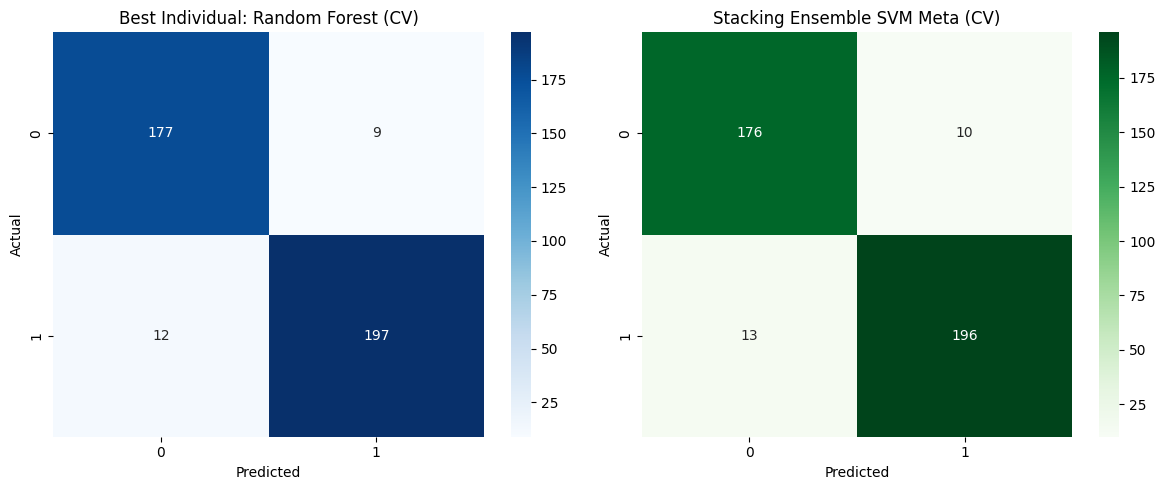

In [ ]:
# Cell 9: Confusion Matrices
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Best individual model (Random Forest via cross_val_predict)
y_pred_rf = cross_val_predict(best_estimators['Random Forest'], X_acad_scaled, y_acad, cv=cv)
cm_best = confusion_matrix(y_acad, y_pred_rf)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Best Individual: Random Forest (CV)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Stacking model with SVM Meta
cm_stack = confusion_matrix(y_acad, y_pred_stack_acad)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Stacking Ensemble SVM Meta (CV)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

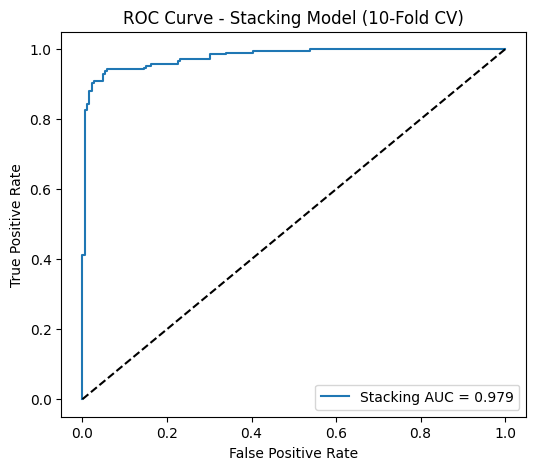

In [ ]:
# Cell 10: ROC Curve for Stacking Model
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_acad, y_proba_stack_acad)
auc_score = roc_auc_score(y_acad, y_proba_stack_acad)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Stacking AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Model (10-Fold CV)")
plt.legend()
plt.show()

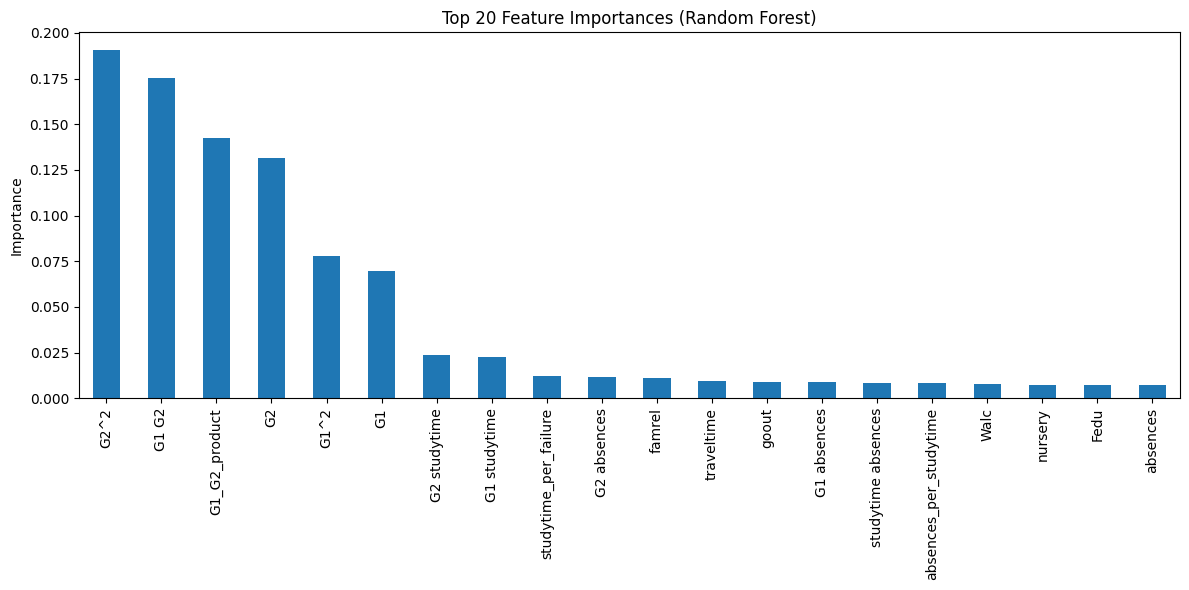

In [ ]:
# Cell 11: Feature Importances (Random Forest)
if 'Random Forest' in best_estimators:
    rf_best = best_estimators['Random Forest']
    importances = rf_best.feature_importances_

    # Use the column names of the enriched dataset
    valid_feature_names = X.columns.tolist()

    feat_imp = pd.Series(importances, index=valid_feature_names).sort_values(ascending=False)

    # Plotting
    feat_imp.head(20).plot(kind='bar', figsize=(12,6))
    plt.title("Top 20 Feature Importances (Random Forest)")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest not in best_estimators.")

In [ ]:
# Cell 11b: Feature selection for academic data using Random Forest importance
if 'Random Forest' in best_estimators_acad:
    rf_best = best_estimators_acad['Random Forest']
    importances = rf_best.feature_importances_

    feat_imp = pd.Series(importances, index=X_acad.columns).sort_values(ascending=False)
    top_features = feat_imp.head(15).index.tolist()
    print("Top 15 academic features:", top_features)

    # Create reduced dataset
    X_acad_selected = X_acad[top_features].copy()

    # Re-scale
    scaler_acad_selected = StandardScaler()
    X_acad_scaled_selected = scaler_acad_selected.fit_transform(X_acad_selected)

    # Re-run stacking on selected features (optional)
    # y_pred_stack_acad_sel = cross_val_predict(stacking_clf_acad, X_acad_scaled_selected, y_acad, cv=cv)
    # print("Accuracy on selected features:", accuracy_score(y_acad, y_pred_stack_acad_sel))

Top 15 academic features: ['G2', 'G1', 'absences', 'failures', 'traveltime', 'studytime', 'famsup', 'schoolsup', 'paid']


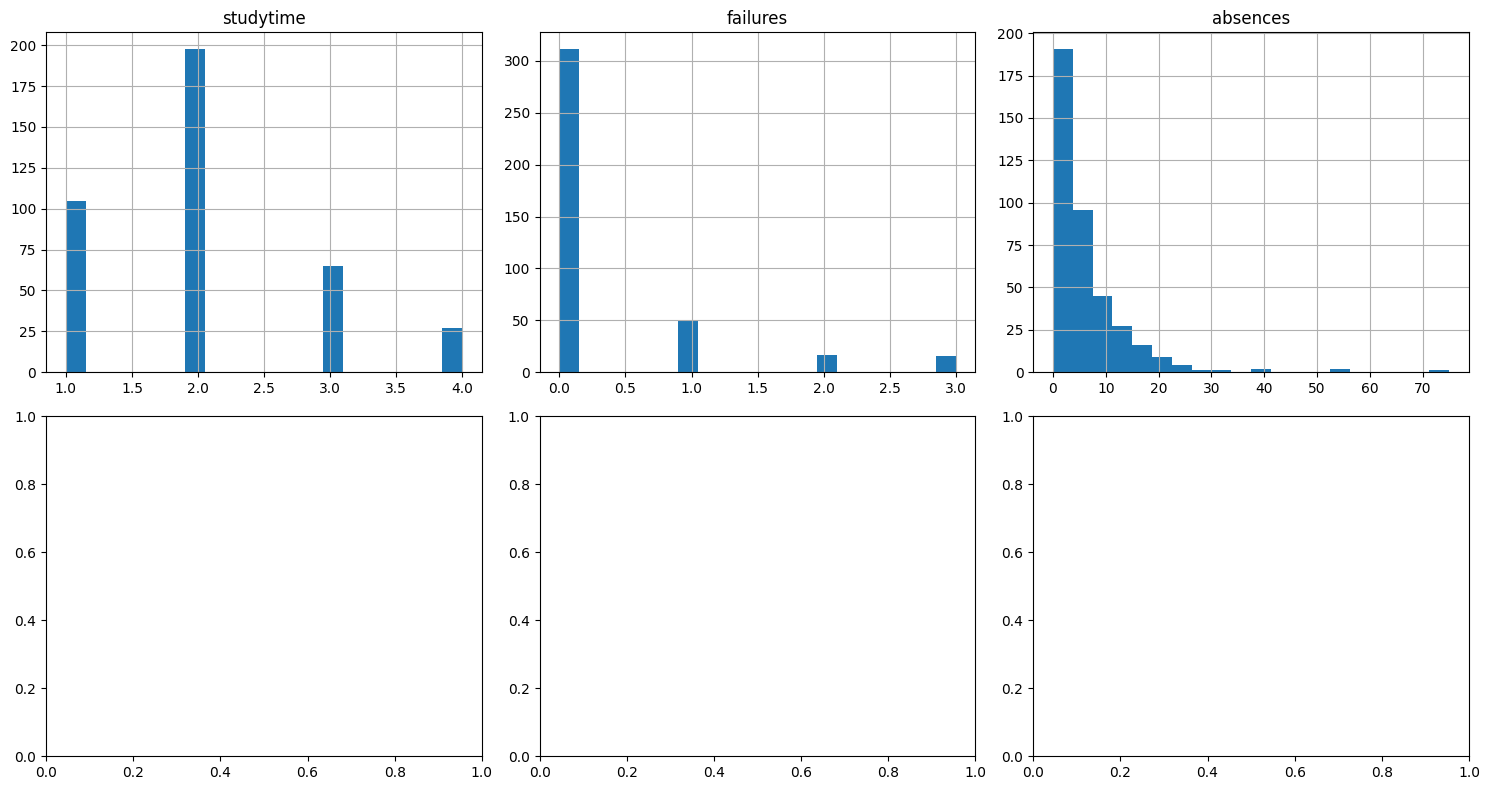

In [ ]:
# CELL 12: Histograms of selected features (unchanged)
fig, axes = plt.subplots(2, 3, figsize=(15,8))
cols_to_plot = ['studytime', 'failures', 'absences']
for i, col in enumerate(cols_to_plot):
    if col in X.columns:
        ax = axes[i//3, i%3]
        X[col].hist(ax=ax, bins=20)
        ax.set_title(col)
plt.tight_layout()
plt.show()

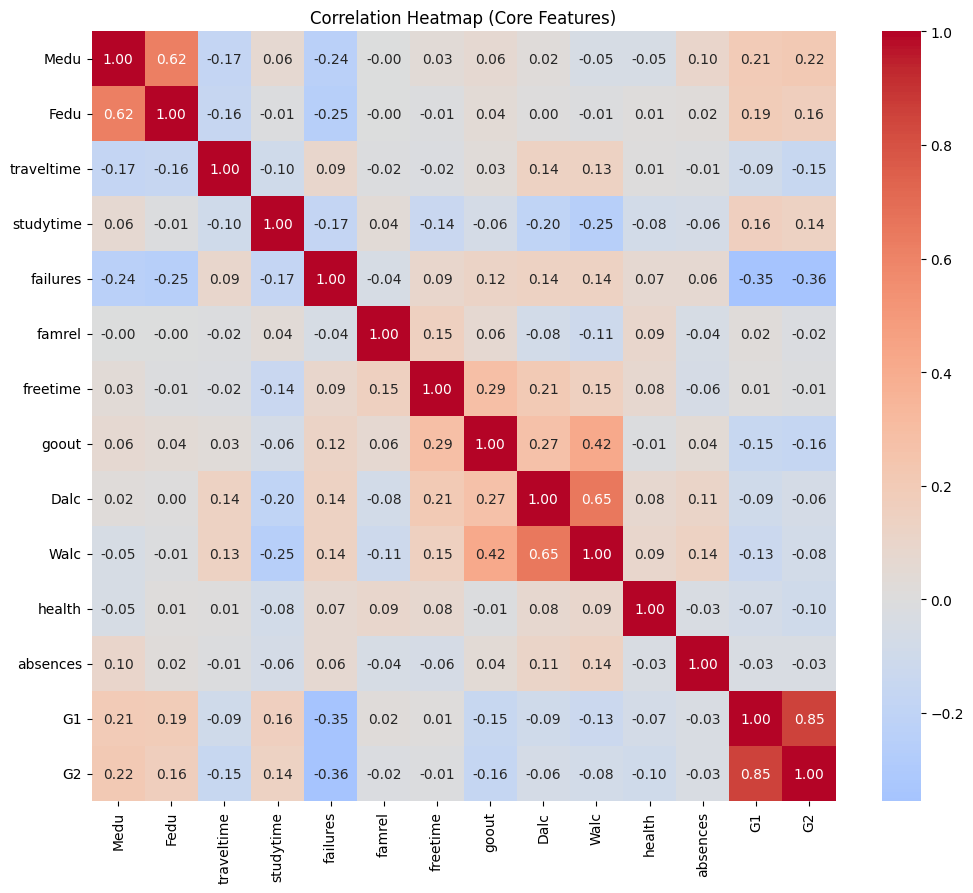

In [ ]:
# CELL 13: Correlation Heatmap (core features)
core_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                 'absences', 'G1', 'G2']
core_features = [f for f in core_features if f in X.columns]
plt.figure(figsize=(12,10))
sns.heatmap(X[core_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Heatmap (Core Features)")
plt.show()

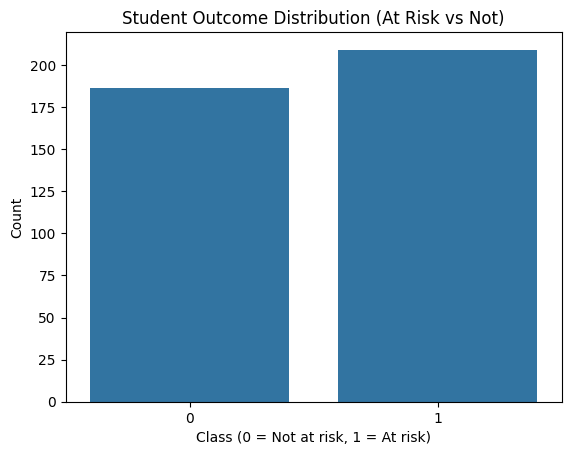

In [ ]:
# CELL 14: Target distribution (unchanged)
sns.countplot(x=y)
plt.title("Student Outcome Distribution (At Risk vs Not)")
plt.xlabel("Class (0 = Not at risk, 1 = At risk)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Cell 15: Final Results Summary
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("="*50)
print("FINAL RESULTS COMPARISON (10-Fold CV)")
print("="*50)

# Stacking ensemble results for Enriched Data (from Cell 7)
acc_stack_enriched = accuracy_score(y, y_pred_stack)
f1_stack_enriched = f1_score(y, y_pred_stack)
auc_stack_enriched = roc_auc_score(y, y_proba_stack)

print("\n--- STACKING ENSEMBLE (Demographic + Academic) ---")
print(f"Accuracy: {acc_stack_enriched:.4f}")
print(f"F1 Score: {f1_stack_enriched:.4f}")
print(f"AUC:      {auc_stack_enriched:.4f}")

# Stacking ensemble results for Academic-Only Data (from Cell 7)
acc_stack_acad = accuracy_score(y_acad, y_pred_stack_acad)
f1_stack_acad = f1_score(y_acad, y_pred_stack_acad)
auc_stack_acad = roc_auc_score(y_acad, y_proba_stack_acad)

print("\n--- STACKING ENSEMBLE (Academic Only) ---")
print(f"Accuracy: {acc_stack_acad:.4f}")
print(f"F1 Score: {f1_stack_acad:.4f}")
print(f"AUC:      {auc_stack_acad:.4f}")

print("\n" + "="*50)
print("Best overall accuracy (Stacking - Academic Only): {:.4f}".format(acc_stack_acad))
print("="*50)

FINAL RESULTS COMPARISON (10-Fold CV)

--- STACKING ENSEMBLE (Demographic + Academic) ---
Accuracy: 0.9291
F1 Score: 0.9324
AUC:      0.9768

--- STACKING ENSEMBLE (Academic Only) ---
Accuracy: 0.9418
F1 Score: 0.9446
AUC:      0.9787

Best overall accuracy (Stacking - Academic Only): 0.9418


Top 5 features: ['G2^2', 'G1 G2', 'G1_G2_product', 'G2', 'G1^2']


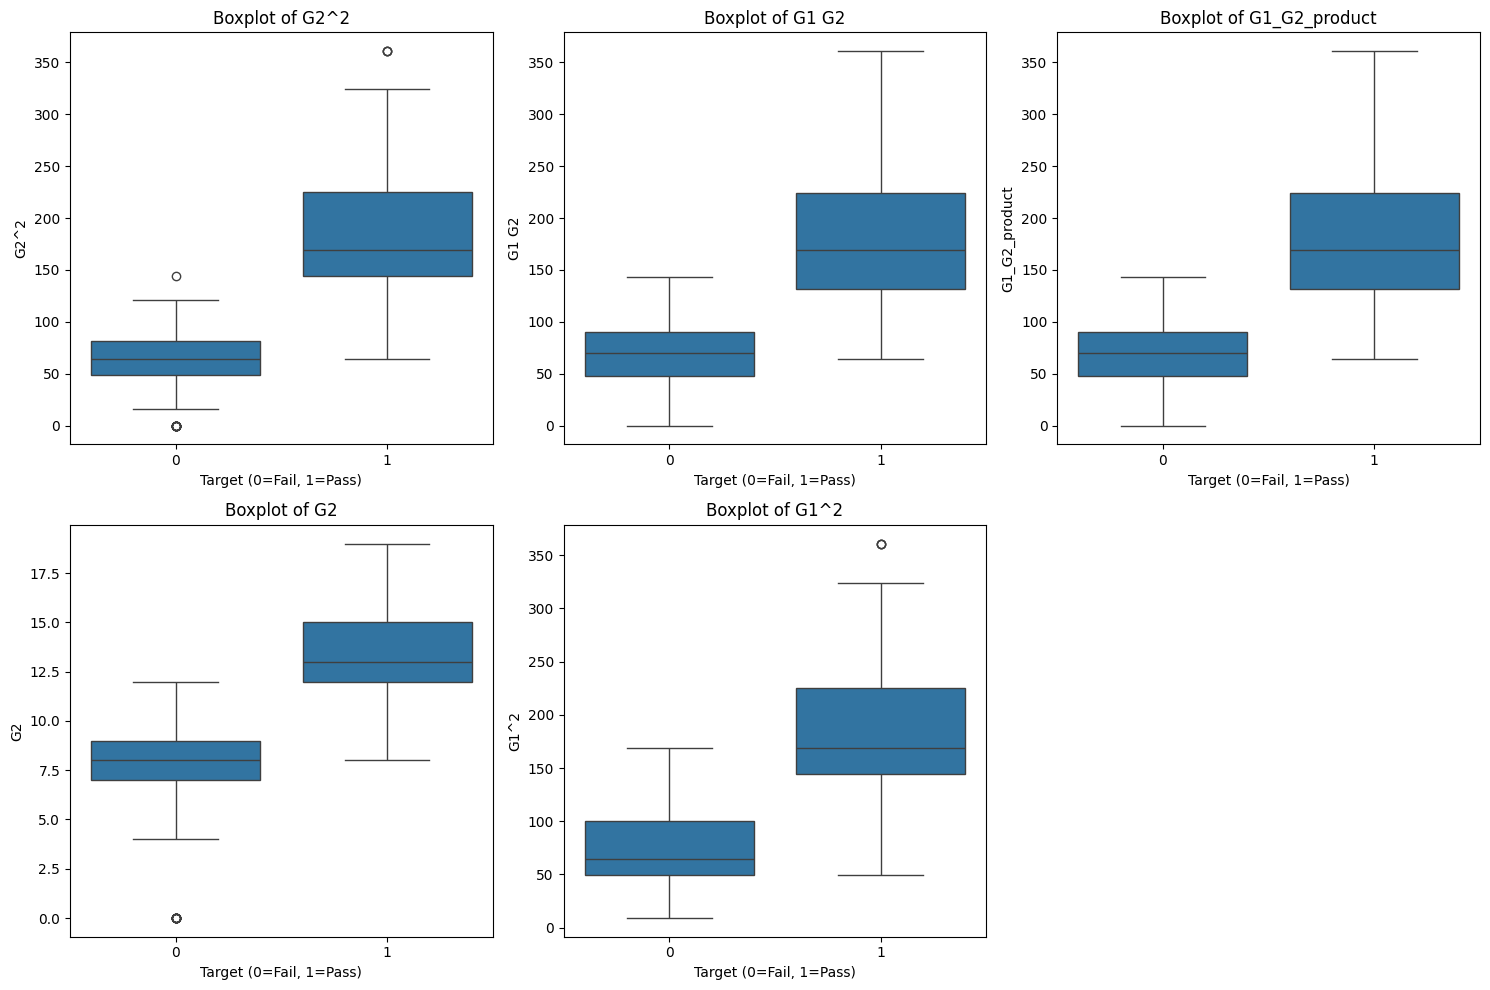

In [ ]:
# Use top features from Random Forest (enriched dataset)
rf_best = best_estimators['Random Forest']
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Select top 5 features for boxplots
top_features = feat_imp.head(5).index.tolist()
print("Top 5 features:", top_features)

# Create boxplots
fig, axes = plt.subplots(2,3, figsize=(15,10))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    sns.boxplot(x=y, y=X[feat], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feat}')
    axes[i].set_xlabel('Target (0=Fail, 1=Pass)')
if len(top_features) < 6:
    axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('boxplots_top_features.png', dpi=300, bbox_inches='tight')
plt.show()

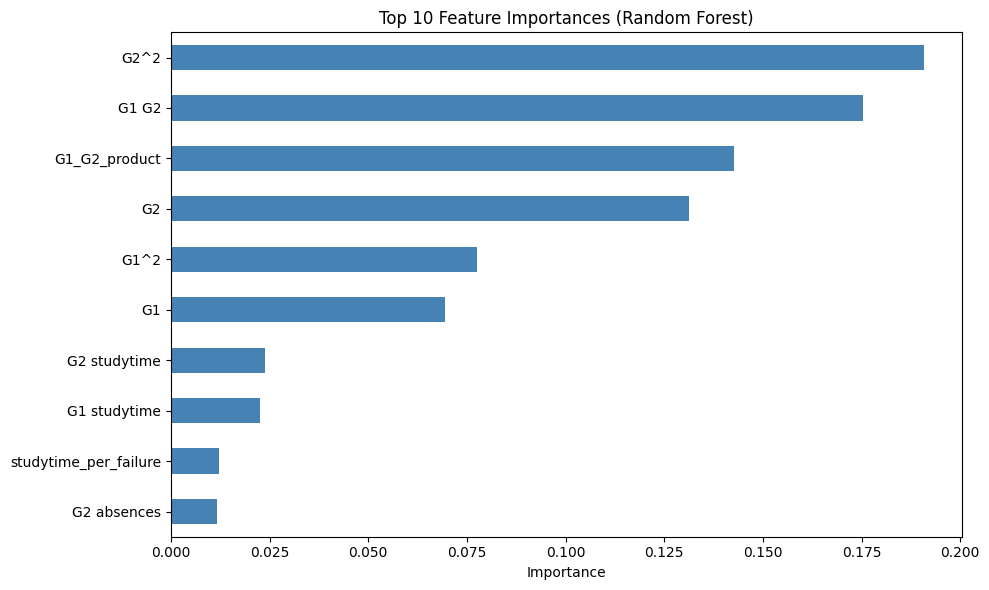

In [ ]:
rf_best = best_estimators['Random Forest']
importances = rf_best.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
feat_imp.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_top10.png', dpi=300, bbox_inches='tight')
plt.show()

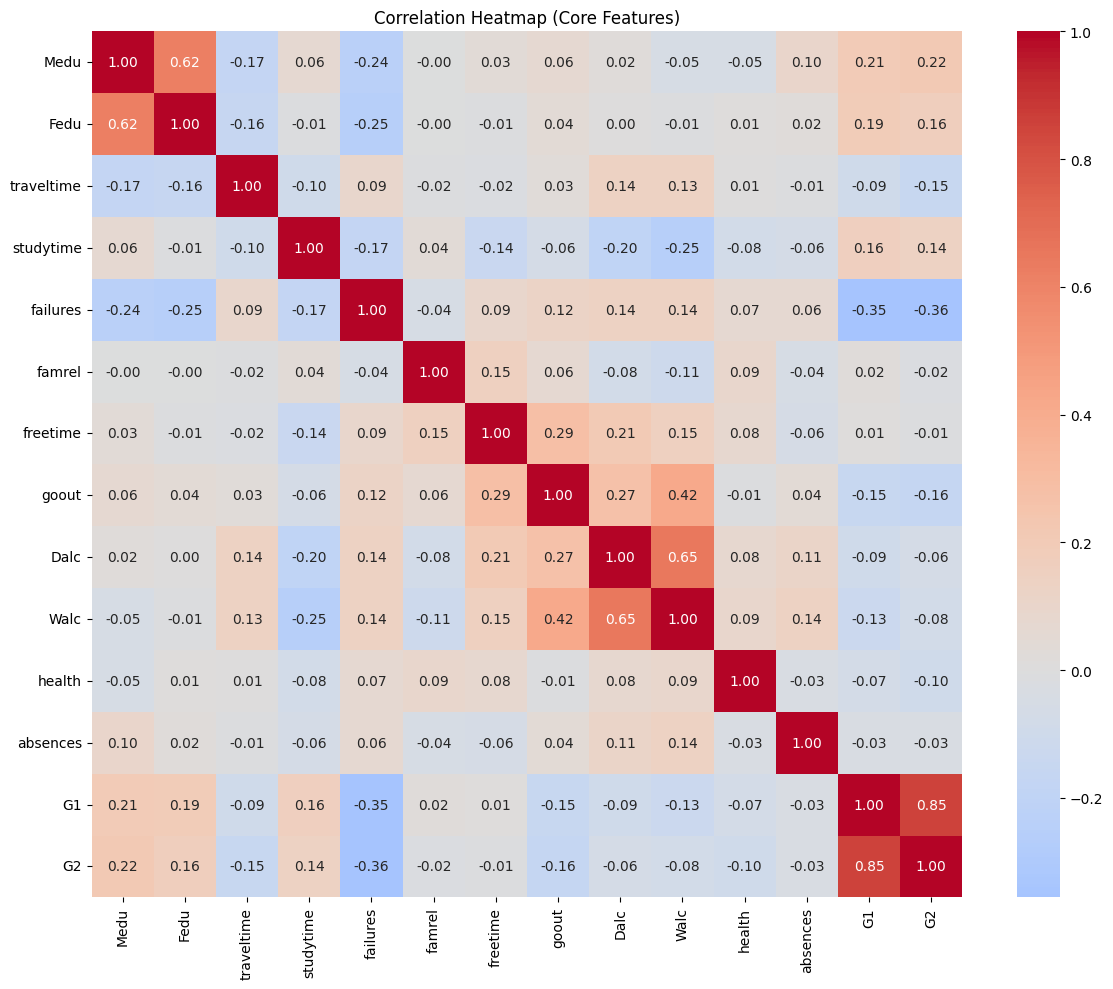

In [ ]:
core_features = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
                 'absences', 'G1', 'G2']
core_features = [f for f in core_features if f in X.columns]

plt.figure(figsize=(12,10))
sns.heatmap(X[core_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title("Correlation Heatmap (Core Features)")
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

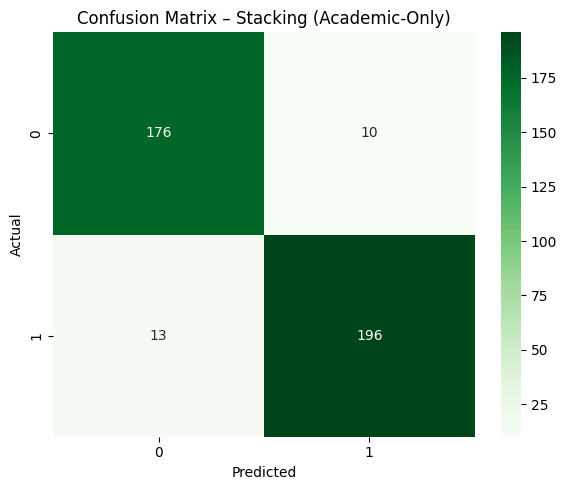

In [ ]:
cm_stack = confusion_matrix(y_acad, y_pred_stack_acad)
plt.figure(figsize=(6,5))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix – Stacking (Academic‑Only)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_stacking.png', dpi=300, bbox_inches='tight')
plt.show()

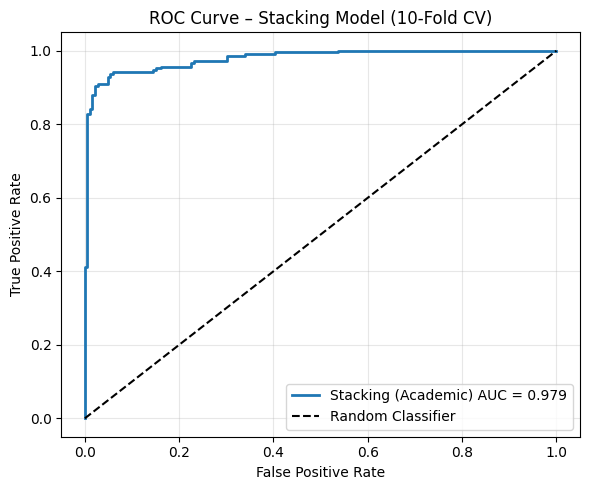

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve and AUC for the academic‑only stacking model
fpr, tpr, _ = roc_curve(y_acad, y_proba_stack_acad)
auc_score = roc_auc_score(y_acad, y_proba_stack_acad)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Stacking (Academic) AUC = {auc_score:.3f}', linewidth=2)
plt.plot([0,1],[0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Stacking Model (10‑Fold CV)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_stacking_academic.png', dpi=300, bbox_inches='tight')
plt.show()